# Yasmin's Notebook
## Education Metric – The Best Neighborhood in Pittsburgh

For my sub-metric, I chose to analyze public school enrollment by neighborhood.  

So I looked at neighborhoods with more K-12 public school students because greater access to educational resources, which can lead to a more active and engaged community.

To measure this, I used the dataset:

**Pittsburgh Public Schools Enrollment by Neighborhood**  
WPRDC Dataset URL:  
https://data.wprdc.org/dataset/pittsburgh-public-schools-enrollment/resource/cbf270fd-891e-49bb-98fb-d6d52c260847

In this notebook, I will:
1. Load the dataset using pandas  
2. Select the relevant columns  
3. Compute the total enrollment per neighborhood  
4. Visualize the top neighborhoods  
5. Identify the best neighborhood according to this education metric  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Load dataset from WPRDC
url = "https://data.wprdc.org/datastore/dump/cbf270fd-891e-49bb-98fb-d6d52c260847"
enroll = pd.read_csv(url)

# Display first few rows
enroll.head()


,_id,neighborhood,african_american,american_indian,asian__not_pacific_islander,hispanic,multiracial,native_hawaiian_or_other_pacific_islander,white,total_students_enrolled,student_count_redactions,attending_feeder,attending_nonfeeder,total_with_feeder_status,feeder_count_redactions,grade_level
0,1,Allegheny Center,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,Pre-K
1,2,Allegheny West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,Pre-K
2,3,Allentown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,Pre-K
3,4,Arlington,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,Pre-K
4,5,Arlington Heights,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,Pre-K


### Cleaning the Dataset

Next, I will clean the neighborhood column and select only the important columns being the total population and neighborhood. 

- neighborhood  
- total_students_enrolled  

I will also convert the enrollment column to numeric so it can be summed.


In [3]:
# Ensure neighborhood is a clean string
enroll["neighborhood"] = enroll["neighborhood"].astype(str).str.strip()

# Select relevant columns
edu = enroll[["neighborhood", "total_students_enrolled"]].copy()

# Convert enrollment to a number
edu["total_students_enrolled"] = pd.to_numeric(
    edu["total_students_enrolled"],
    errors="coerce"
)

edu.head()


,neighborhood,total_students_enrolled
0,Allegheny Center,NaN
1,Allegheny West,NaN
2,Allentown,NaN
3,Arlington,NaN
4,Arlington Heights,NaN


### Education Access Score

Here I'll find the Education Access Score:

Total number of students enrolled in public schools in each neighborhood.

This tells us which neighborhoods have the strongest education presence. 


In [4]:
edu_metric = (
    edu.groupby("neighborhood")["total_students_enrolled"]
    .sum()
    .reset_index()
    .sort_values("total_students_enrolled", ascending=False)
)

edu_metric.head(10)


,neighborhood,total_students_enrolled
15,Carrick,1276.0
13,Brookline,1169.0
7,Beechview,794.0
69,Sheraden,694.0
77,Squirrel Hill South,679.0
43,Knoxville,616.0
12,Brighton Heights,598.0
40,Homewood North,589.0
26,East Hills,569.0
38,Hazelwood,567.0


### Top 15 Neighborhoods by Student Enrollment

This bar chart shows which neighborhoods have the highest student populations.


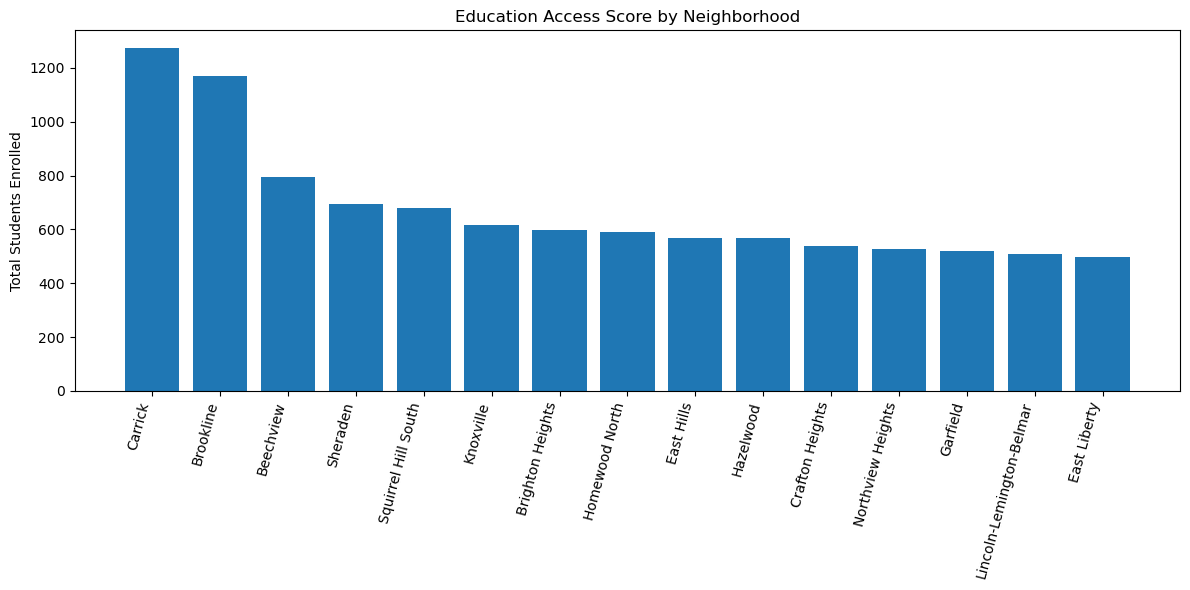

In [5]:
top15 = edu_metric.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top15["neighborhood"], top15["total_students_enrolled"])
plt.ylabel("Total Students Enrolled")
plt.xticks(rotation=75, ha="right")
plt.title("Education Access Score by Neighborhood")
plt.tight_layout()
plt.show()


### Identifying the Best Neighborhood by the Education Metric

The neighborhood with the highest total student enrollment.


In [6]:
best_neighborhood = edu_metric.iloc[0]
best_neighborhood


neighborhood               Carrick
total_students_enrolled     1276.0
Name: 15, dtype: object

In [7]:
print(
    "According to the Education Access Score, the best neighborhood for education is:",
    best_neighborhood["neighborhood"],
    "with",
    int(best_neighborhood["total_students_enrolled"]),
    "students enrolled."
)


According to the Education Access Score, the best neighborhood for education is: Carrick with 1276 students enrolled.


## Conclusion – Yasmin


Carrick had the highest enrollment at 1,276 students, but the difference compared to neighborhoods like Brookline (1,169) and Beechview (794) is not large enough to say it is clearly the best based on education alone. This small margin shows that several neighborhoods have similarly strong educational presence. When combined wit metrics on air quality and safety, it becomes clear that Carrick is not necessarily the overall best. 
